Basic library imports and some precautionary cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
marketingDF = pd.read_csv("ifood_df.csv")
marketingDF = marketingDF.dropna(subset=["Income", "Age"])

backupMarketingDF = marketingDF.copy()

marketingDF.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


More cleaning

I chose the IQR method because I am not super familiar with this data set or the domain.

In [2]:
import numpy as np

Q1 = np.percentile(marketingDF['Income'], 25, method='midpoint')
Q3 = np.percentile(marketingDF['Income'], 75, method='midpoint')
IQR = Q3 - Q1

IQR

np.float64(33085.0)

In [3]:
maxThreshold = Q3+1.5*IQR
minThreshold = Q1-1.5*IQR


marketingDF = marketingDF[marketingDF["Income"] < maxThreshold]
marketingDF = marketingDF[marketingDF["Income"] > minThreshold]
marketingDF.tail()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
2200,61223.0,0,1,46,709,43,182,42,118,247,...,0,0,0,0,1,0,0,1094,847,0
2201,64014.0,2,1,56,406,0,30,0,0,8,...,1,0,0,0,0,0,1,436,428,1
2202,56981.0,0,0,91,908,48,217,32,12,24,...,0,0,0,0,1,0,0,1217,1193,1
2203,69245.0,0,1,8,428,30,214,80,30,61,...,1,0,0,0,0,1,0,782,721,0
2204,52869.0,1,1,40,84,3,61,2,1,21,...,0,0,0,0,0,0,1,151,130,0


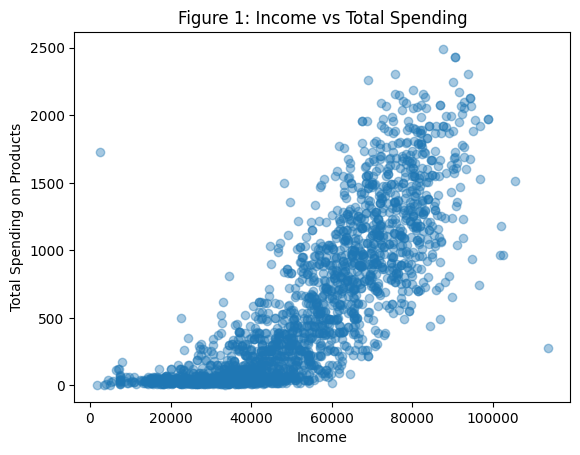

In [4]:
plt.figure()
plt.scatter(marketingDF["Income"], marketingDF["MntTotal"], alpha=0.4)
plt.xlabel("Income")
plt.ylabel("Total Spending on Products")
plt.title("Figure 1: Income vs Total Spending")
plt.show()


In [5]:
corr_value = marketingDF["Income"].corr(marketingDF["MntTotal"])
print(corr_value)


0.8230660021398378


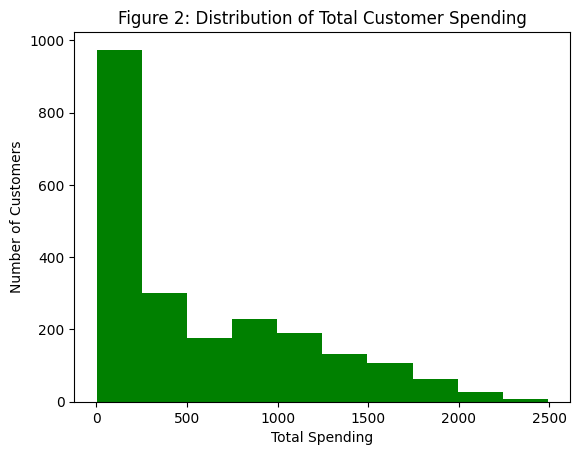

In [6]:
plt.figure()
plt.hist(marketingDF["MntTotal"], color="green")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.title("Figure 2: Distribution of Total Customer Spending")
plt.show()


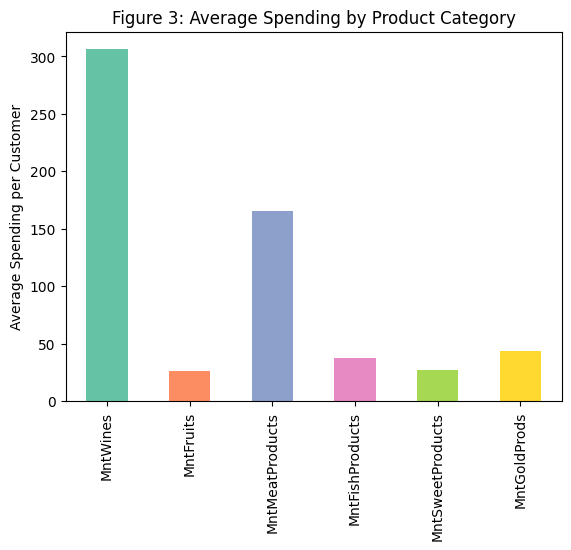

In [7]:
categoryCols = ["MntWines","MntFruits","MntMeatProducts", "MntFishProducts","MntSweetProducts","MntGoldProds"]
avgSpend = marketingDF[categoryCols].mean()

colors = plt.cm.Set2(range(len(categoryCols)))

plt.figure()
avgSpend.plot(kind="bar", color=colors)
plt.ylabel("Average Spending per Customer")
plt.title("Figure 3: Average Spending by Product Category")
plt.show()



<Figure size 640x480 with 0 Axes>

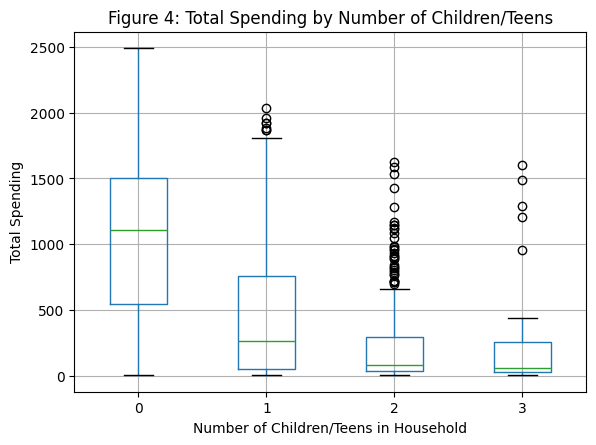

In [8]:
marketingDF["KidsTotal"] = marketingDF["Kidhome"] + marketingDF["Teenhome"]
plt.figure()
marketingDF.boxplot(column="MntTotal", by="KidsTotal")
plt.xlabel("Number of Children/Teens in Household")
plt.ylabel("Total Spending")
plt.title("Figure 4: Total Spending by Number of Children/Teens")
plt.suptitle("")
plt.show()


<Figure size 640x480 with 0 Axes>

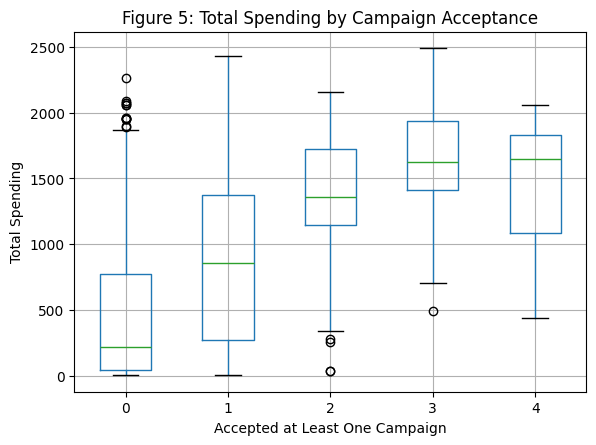

In [9]:
plt.figure()
marketingDF.boxplot(column="MntTotal", by="AcceptedCmpOverall")
plt.xlabel("Accepted at Least One Campaign")
plt.ylabel("Total Spending")
plt.title("Figure 5: Total Spending by Campaign Acceptance")
plt.suptitle("")
plt.show()


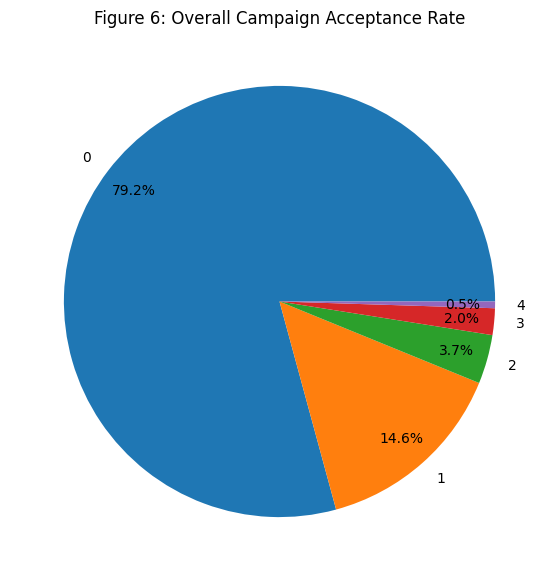

In [10]:
sizes = marketingDF["AcceptedCmpOverall"].value_counts()
labels = sizes.index.astype(str) 

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", pctdistance=.85)
plt.title("Figure 6: Overall Campaign Acceptance Rate")
plt.show()
